# Signal Blackouts: Tracking a City Shuttle through GNSS Dropouts

## Roman Branovets, Skoltech, 2025

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

### Trajectory generation

**True trajectory of a city shuttle path**

Generating a true trajectory of the coordinate $𝒙_𝒊$ of an object's motion, perturbed by
normally distributed random acceleration $𝑎_𝑖$ with variance $\sigma^2_𝑎 = 0.2^2  (m/s^2)^2$. The trajectory
will consist of 200 points, starting with initial conditions $𝑥_0 = 5 m$. , $𝑉_0 = 1$ m/s. and a time
step $𝑇 = 1$ s.

$$
\begin{aligned}
x_i &= x_{i-1} + V_{i-1}T + \frac{a_i T^2}{2}\\
V_i &= V_{i-1} + a_i T
\end{aligned}
$$

In [73]:
#generating_trajectory
steps=200
x_real=np.zeros(steps)
v_real=np.zeros(steps)
t=1
x_real[0]=5
v_real[0]=1
for i in range(1,steps):
    a = np.random.normal(0,0.2)
    x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
    v_real[i]=v_real[i-1]+a*t

**Measurements**  
Generate measurements $z_i$ of the coordinate $x_i$ as follows:  

$$z_i = x_i + \eta_i$$

$\eta_i$ is normally distributed random noise with a mean of zero and a variance of $\sigma_\eta^2 = 20^2$.  

However, there are measurement gaps with a probability of $P = 0.2$. To create the measurements with gaps, create the random value $\xi$ that is randomly distributed at every step $i$. If $\xi_i \leq P$, then $z(i) = NaN$ (gap), if $\xi_i > P$, then $z_i = x_i + \eta_i$.

In [74]:
#generating_measurements
z = np.zeros(steps)
p = 0.2
for i in range(0,steps):
    xi =  np.random.random()
    if xi > p:
        z[i] = x_real[i] + np.random.normal(0, 20)
    else:
        z[i] = np.nan

### Kalman filter algorithm to estimate the state vector $X_i$

Let's define the parameters of this system

$$
\begin{aligned}
X_i &= \Phi X_{i-1} + Ga_i \\
z_i &= H_i X_i + \eta_i
\end{aligned}
$$

Where

- $X_{i}$ is the state vector
- $\Phi$ is the transition matrix that relates $X_{i}$ and $X_{i-1}$
- $G$ is the input matrix that defines how the random acceleration $a_{i}$ influences the state vector
- $z_{i}$ is the measurement vector, which in this case consists of a measurement of the coordinate $x_{i}$
- $H$ is the observation matrix that relates the measurement vector to the state vector
- $\eta_{i}$ is the measurement noise with the covariance matrix $R_{i}$

In [75]:
#transition matrix
fi=np.matrix([[1,t],[0,1]])
#input matrix
g=np.matrix([[(t**2)/2],[t]])
#observation matrix
h=np.matrix([1,0])
#state vector
X = np.zeros((len(x_real), 2, 1))
X_tuned = np.zeros((len(x_real), 2, 1))
for i in range(len(x_real)):
    X[i] = np.array([[x_real[i]], [v_real[i]]])

Developing the forward Kalman filter algorithm

In [76]:
#Initial filtered estimate
X[0]=np.matrix([[2],[0]])
X_tuned[0]=np.matrix([[2],[0]])
#Filtration error covariance matrix
P=np.zeros((steps, 2, 2))
P[0]=np.matrix([[10000, 0], [0, 10000]])
#Covariance matrix
Q=(g@g.T)*(0.2**2)
R = np.array(20**2)
K = np.zeros((steps, 2, 1))
m = 7
for i in range(1,len(x_real)):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)/E
    if not np.isnan(z[i]):
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
    if i < steps-m+1:
        X_tuned[i+m-1]=(fi**6)@X[i]

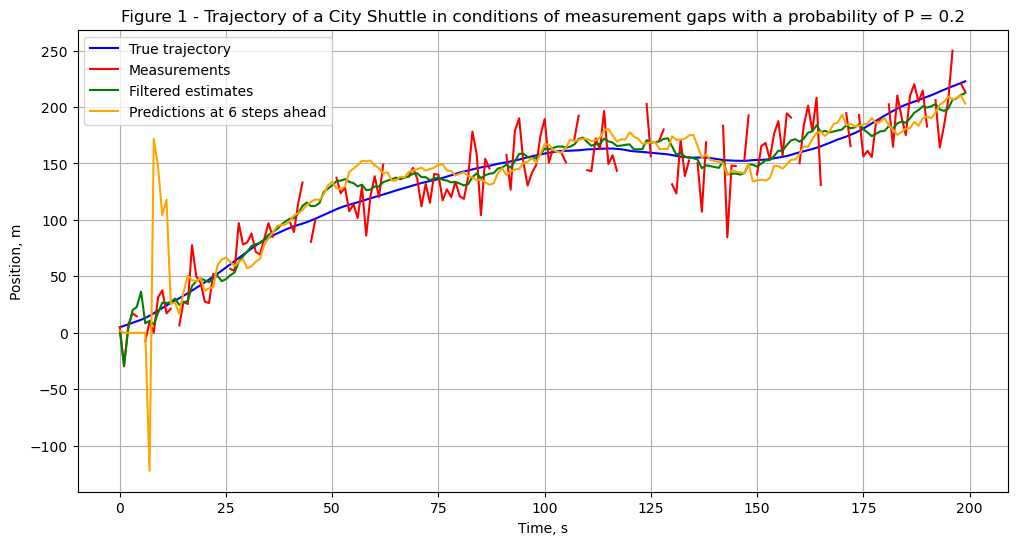

In [77]:
#Plots of true coordinates, measurements, filtered estimates and predictions at 6 steps ahead
plt.figure(figsize=(12, 6))
plt.plot(x_real, color="blue",  label='True trajectory')
plt.plot(z, color='red', label='Measurements')
plt.plot(X[:,0,0], color='green',  label='Filtered estimates')
plt.plot(X_tuned[:,0,0], color='orange',  label='Predictions at 6 steps ahead')
plt.title('Figure 1 - Trajectory of a City Shuttle in conditions of measurement gaps with a probability of P = 0.2')
plt.xlabel('Time, s')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

###  Error estimation

* Obtain estimates of state vector $X_{i}$ using the Kalman filter over $M=500$ runs. Compare the true errors with the calculated errors (as defined by the filter) for the following:  
  * _Filtered_ estimates of the coordinate $x_{i}$;  
  * _Predicted estimate_ $x_{i+1,i}$ (1-step ahead, derived from the _prediction_ step);  
  * _Predicted estimate_ $x_{i+m-1,i}$ ($m-1$-step ahead, where $m=7$).

In [78]:
# function for find calculated error of 6-step ahead
def calc_err_finder(P, fi, Q, i=0):
    if i == 6:
        return fi@P@fi.T + Q
    i += 1
    return fi@calc_err_finder(P, fi, Q, i)@fi.T + Q

In [79]:
#calculate error for filtration, prediction and prediction of 6-step ahead
M=500
error_filt=np.zeros((M,steps))
error_pred=np.zeros((M,steps))
error_tuned=np.zeros((M,steps))
fin_err_filt=np.zeros(steps)
fin_err_pred=np.zeros(steps)
fin_err_tuned=np.zeros(steps)
for o in range(M):
    #generating_trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z = np.zeros(steps)
    p = 0.2
    for i in range(0,steps):
        xi =  np.random.random()
        if xi > p:
            z[i] = x_real[i] + np.random.normal(0, 20)
        else:
            z[i] = np.nan
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matri
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    X_pred = np.zeros((len(x_real), 2, 1))
    X_tuned = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0]])
    X_pred[0]=np.matrix([[2],[0]])
    X_tuned[0:m]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[100, 0], [0, 100]])
    P_viz=np.zeros((steps, 2, 2))
    P_viz[0]=np.matrix([[100, 0], [0, 100]])
    P_tuned=np.zeros((steps, 2, 2))
    P_tuned[0:m]=np.matrix([[100, 0], [0, 100]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        X_pred[i] = fi@X[i-1]
        if i>1:
            error_pred[o,i]=(x_real[i]-X_pred[i,0,0])**2
        P[i]=(fi@P[i-1]@fi.T)+Q
        P_viz[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        if not np.isnan(z[i]):
            X[i]=X[i]+K[i]*(z[i]-h@X[i])
            P[i]=(np.identity(2)-K[i]@h)@P[i]
        if i < steps-m+1:
            X_tuned[i+m-1]=(fi**6)@X[i]
            P_tuned[i+m-1] = calc_err_finder(P[i], fi, Q)
        if i > 1:
            error_filt[o, i] = (x_real[i]-X[i,0,0])**2
            error_tuned[o, i] = (x_real[i]-X_tuned[i,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_err_filt[i]=fin_err_filt[i]+((1/(M-1))*error_filt[j,i])
        fin_err_pred[i]=fin_err_pred[i]+((1/(M-1))*error_pred[j,i])
        fin_err_tuned[i]=fin_err_tuned[i]+((1/(M-1))*error_tuned[j,i])
    fin_err_filt[i] = sqrt(fin_err_filt[i])
    fin_err_pred[i] = sqrt(fin_err_pred[i])
    fin_err_tuned[i] = sqrt(fin_err_tuned[i])

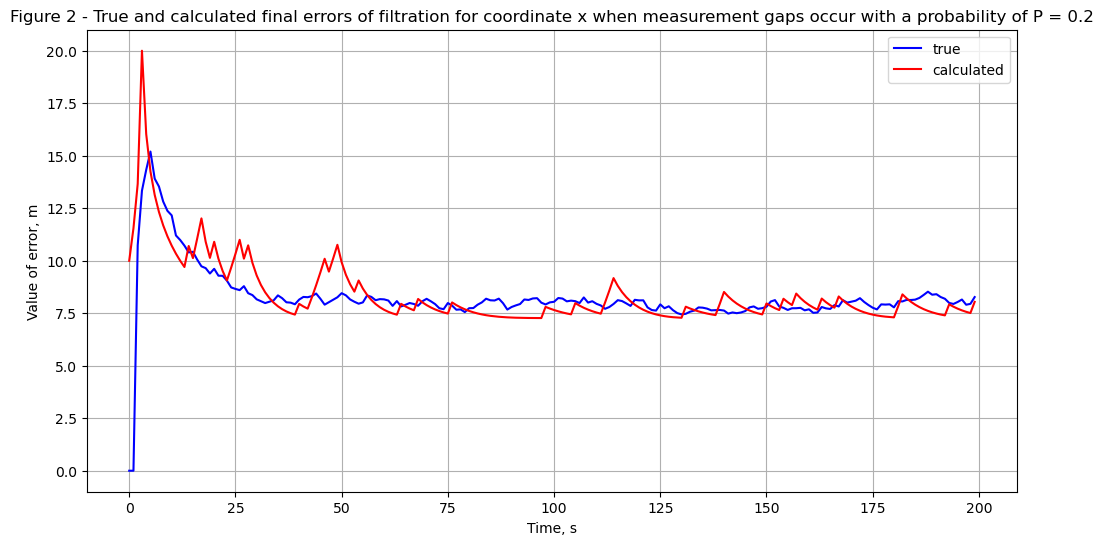

In [80]:
#Plot of the final error of filtration
plt.figure(figsize=(12, 6))
plt.plot(fin_err_filt, color="blue", label='true')
plt.plot(np.sqrt(P[:, 0, 0]), color="red", label='calculated')
plt.title('Figure 2 - True and calculated final errors of filtration for coordinate x when measurement gaps occur with a probability of P = 0.2')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.grid()
plt.legend()
plt.show()

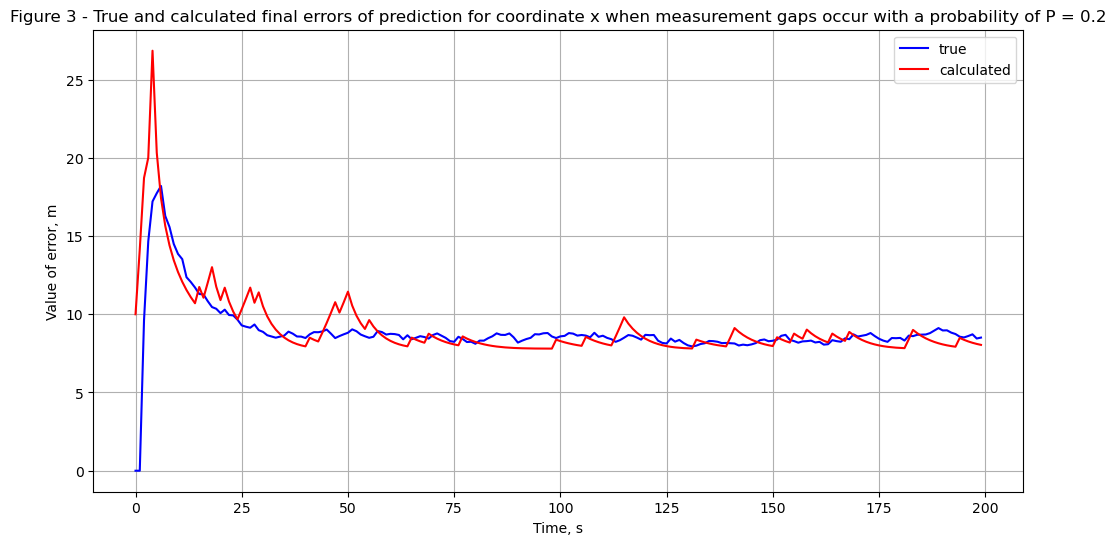

In [81]:
#Plot of the final error of prediction
plt.figure(figsize=(12, 6))
plt.plot(fin_err_pred, color="blue", label='true')
plt.plot(np.sqrt(P_viz[:, 0, 0]), color="red", label='calculated')
plt.title('Figure 3 - True and calculated final errors of prediction for coordinate x when measurement gaps occur with a probability of P = 0.2')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.grid()
plt.legend()
plt.show()

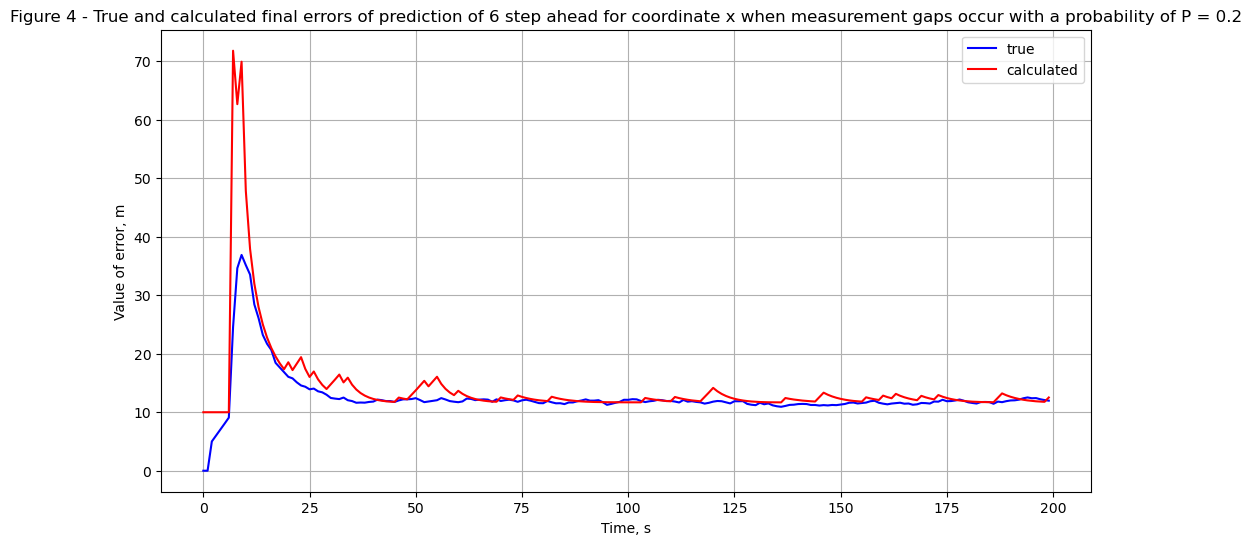

In [82]:
#Plot of the final error of prediction of 6-step ahead
plt.figure(figsize=(12, 6))
plt.plot(fin_err_tuned, color="blue", label='true')
plt.plot(np.sqrt(P_tuned[:, 0, 0]), color="red", label='calculated')
plt.title('Figure 4 - True and calculated final errors of prediction of 6 step ahead for coordinate x when measurement gaps occur with a probability of P = 0.2')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.grid()
plt.legend()
plt.show()

We observe some fluctuations in the calculated error, which are caused by skipping the filtering step in the Kalman filter at a time when measurements are unavailable. The calculated error is asymptotically the same as the true one. When predicting 6 steps ahead, we see the largest error compared to the rest of the cases.

Let's check with a measurement gaps probability $P = 0.3$.

In [83]:
#generating_measurements
z = np.zeros(steps)
p = 0.3
for i in range(0,steps):
    xi =  np.random.random()
    if xi > p:
        z[i] = x_real[i] + np.random.normal(0, 20)
    else:
        z[i] = np.nan

In [84]:
#transition matrix
fi=np.matrix([[1,t],[0,1]])
#input matrix
g=np.matrix([[(t**2)/2],[t]])
#observation matrix
h=np.matrix([1,0])
#state vector
X = np.zeros((len(x_real), 2, 1))
X_tuned = np.zeros((len(x_real), 2, 1))
for i in range(len(x_real)):
    X[i] = np.array([[x_real[i]], [v_real[i]]])

In [85]:
#Initial filtered estimate
X[0]=np.matrix([[2],[0]])
X_tuned[0]=np.matrix([[2],[0]])
#Filtration error covariance matrix
P=np.zeros((steps, 2, 2))
P[0]=np.matrix([[10000, 0], [0, 10000]])
#Covariance matrix
Q=(g@g.T)*(0.2**2)
R = np.array(20**2)
K = np.zeros((steps, 2, 1))
m = 7
for i in range(1,len(x_real)):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)/E
    if not np.isnan(z[i]):
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
    if i < steps-m+1:
        X_tuned[i+m-1]=(fi**6)@X[i]

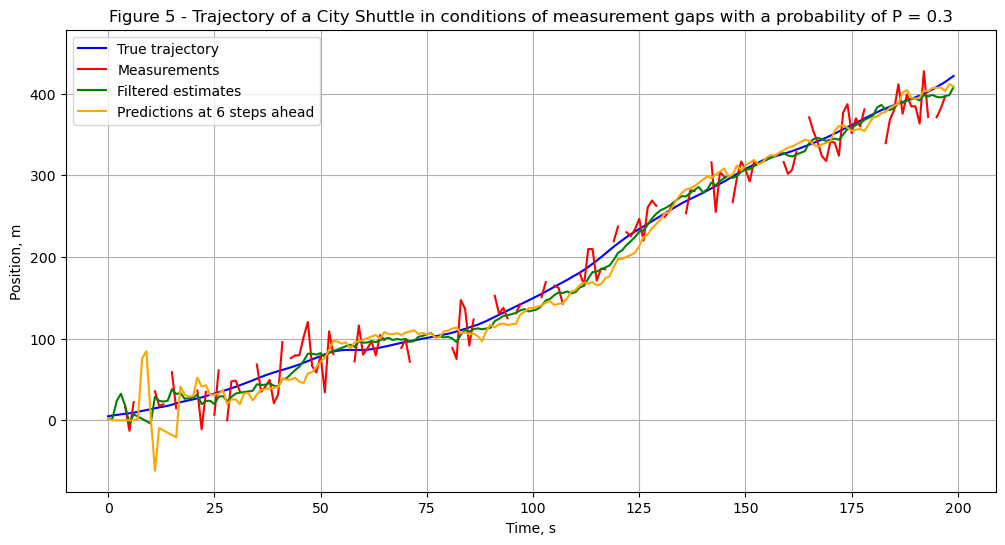

In [86]:
#Plots of true coordinates, measurements, filtered estimates and predictions at 6 steps ahead
plt.figure(figsize=(12, 6))
plt.plot(x_real, color="blue",  label='True trajectory')
plt.plot(z, color='red', label='Measurements')
plt.plot(X[:,0,0], color='green',  label='Filtered estimates')
plt.plot(X_tuned[:,0,0], color='orange',  label='Predictions at 6 steps ahead')
plt.title('Figure 5 - Trajectory of a City Shuttle in conditions of measurement gaps with a probability of P = 0.3')
plt.xlabel('Time, s')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

In [87]:
#calculate error for filtration, prediction and prediction of 6-step ahead
M=500
error_filt=np.zeros((M,steps))
error_pred=np.zeros((M,steps))
error_tuned=np.zeros((M,steps))
fin_err_filt=np.zeros(steps)
fin_err_pred=np.zeros(steps)
fin_err_tuned=np.zeros(steps)
for o in range(M):
    #generating_trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z = np.zeros(steps)
    p = 0.3
    for i in range(0,steps):
        xi =  np.random.random()
        if xi > p:
            z[i] = x_real[i] + np.random.normal(0, 20)
        else:
            z[i] = np.nan
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matri
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    X_pred = np.zeros((len(x_real), 2, 1))
    X_tuned = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0]])
    X_pred[0]=np.matrix([[2],[0]])
    X_tuned[0:m]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[100, 0], [0, 100]])
    P_viz=np.zeros((steps, 2, 2))
    P_viz[0]=np.matrix([[100, 0], [0, 100]])
    P_tuned=np.zeros((steps, 2, 2))
    P_tuned[0:m]=np.matrix([[100, 0], [0, 100]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        X_pred[i] = fi@X[i-1]
        if i>1:
            error_pred[o,i]=(x_real[i]-X_pred[i,0,0])**2
        P[i]=(fi@P[i-1]@fi.T)+Q
        P_viz[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        if not np.isnan(z[i]):
            X[i]=X[i]+K[i]*(z[i]-h@X[i])
            P[i]=(np.identity(2)-K[i]@h)@P[i]
        if i < steps-m+1:
            X_tuned[i+m-1]=(fi**6)@X[i]
            P_tuned[i+m-1] = calc_err_finder(P[i], fi, Q)
        if i > 1:
            error_filt[o, i] = (x_real[i]-X[i,0,0])**2
            error_tuned[o, i] = (x_real[i]-X_tuned[i,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_err_filt[i]=fin_err_filt[i]+((1/(M-1))*error_filt[j,i])
        fin_err_pred[i]=fin_err_pred[i]+((1/(M-1))*error_pred[j,i])
        fin_err_tuned[i]=fin_err_tuned[i]+((1/(M-1))*error_tuned[j,i])
    fin_err_filt[i] = sqrt(fin_err_filt[i])
    fin_err_pred[i] = sqrt(fin_err_pred[i])
    fin_err_tuned[i] = sqrt(fin_err_tuned[i])

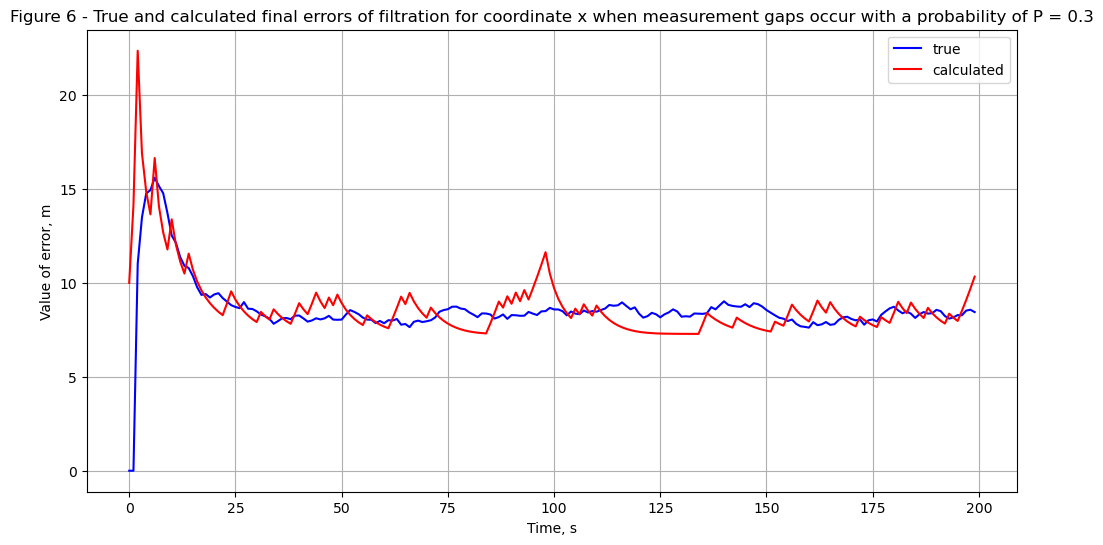

In [88]:
#Plot of the final error of filtration
plt.figure(figsize=(12, 6))
plt.plot(fin_err_filt, color="blue", label='true')
plt.plot(np.sqrt(P[:, 0, 0]), color="red", label='calculated')
plt.title('Figure 6 - True and calculated final errors of filtration for coordinate x when measurement gaps occur with a probability of P = 0.3')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.grid()
plt.legend()
plt.show()

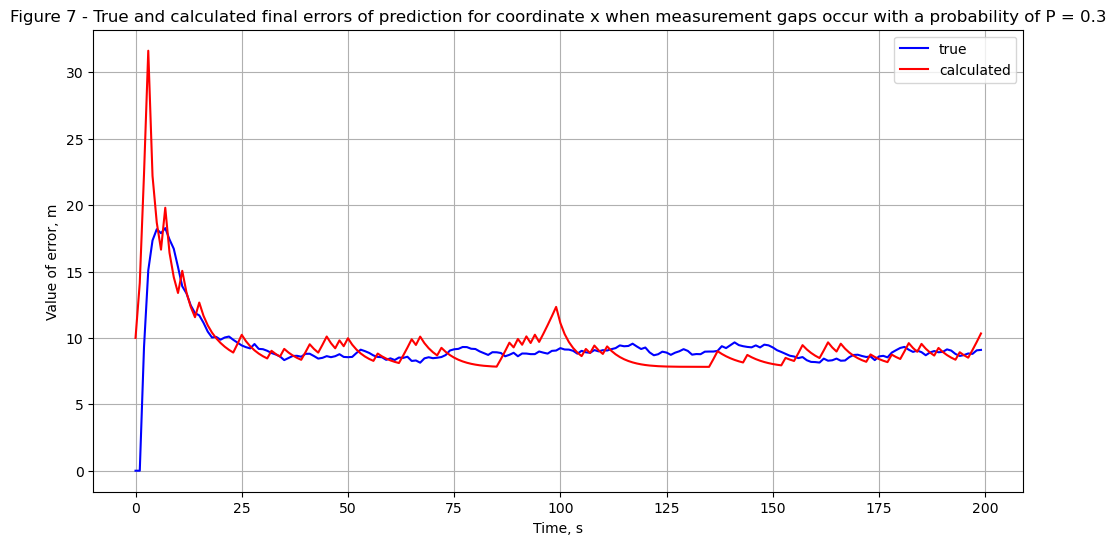

In [89]:
#Plot of the final error of prediction
plt.figure(figsize=(12, 6))
plt.plot(fin_err_pred, color="blue", label='true')
plt.plot(np.sqrt(P_viz[:, 0, 0]), color="red", label='calculated')
plt.title('Figure 7 - True and calculated final errors of prediction for coordinate x when measurement gaps occur with a probability of P = 0.3')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.grid()
plt.legend()
plt.show()

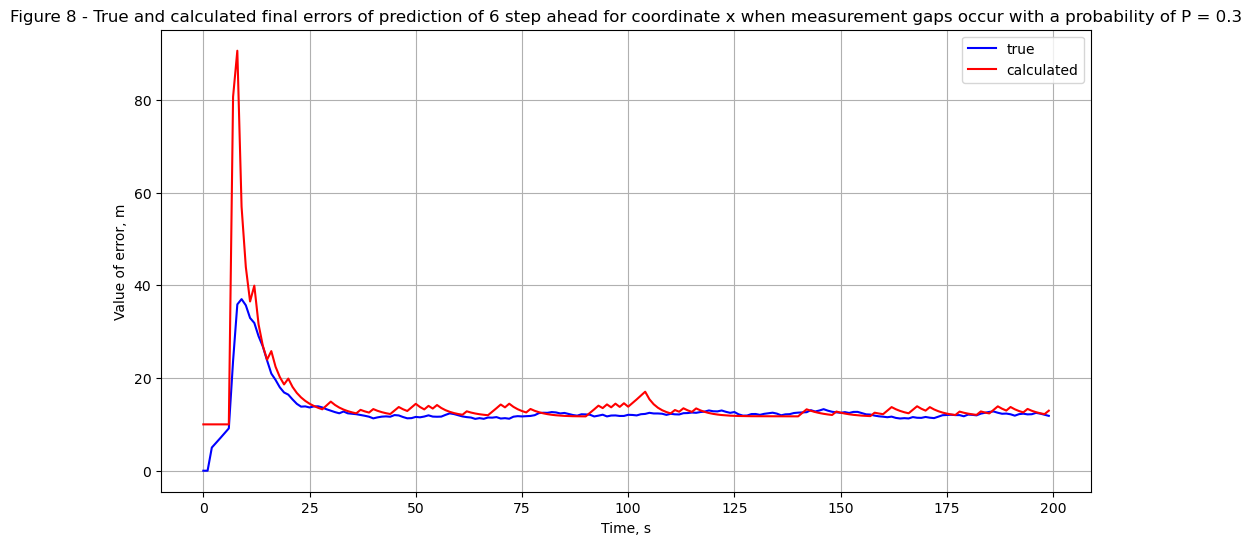

In [90]:
#Plot of the final error of prediction of 6-step ahead
plt.figure(figsize=(12, 6))
plt.plot(fin_err_tuned, color="blue", label='true')
plt.plot(np.sqrt(P_tuned[:, 0, 0]), color="red", label='calculated')
plt.title('Figure 8 - True and calculated final errors of prediction of 6 step ahead for coordinate x when measurement gaps occur with a probability of P = 0.3')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.grid()
plt.legend()
plt.show()

Let's check with a measurement gaps probability $P = 0.5$.

In [91]:
#generating_measurements
z = np.zeros(steps)
p = 0.5
for i in range(0,steps):
    xi =  np.random.random()
    if xi > p:
        z[i] = x_real[i] + np.random.normal(0, 20)
    else:
        z[i] = np.nan

In [92]:
#transition matrix
fi=np.matrix([[1,t],[0,1]])
#input matrix
g=np.matrix([[(t**2)/2],[t]])
#observation matrix
h=np.matrix([1,0])
#state vector
X = np.zeros((len(x_real), 2, 1))
X_tuned = np.zeros((len(x_real), 2, 1))
for i in range(len(x_real)):
    X[i] = np.array([[x_real[i]], [v_real[i]]])

In [93]:
#Initial filtered estimate
X[0]=np.matrix([[2],[0]])
X_tuned[0]=np.matrix([[2],[0]])
#Filtration error covariance matrix
P=np.zeros((steps, 2, 2))
P[0]=np.matrix([[10000, 0], [0, 10000]])
#Covariance matrix
Q=(g@g.T)*(0.2**2)
R = np.array(20**2)
K = np.zeros((steps, 2, 1))
m = 7
for i in range(1,len(x_real)):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)/E
    if not np.isnan(z[i]):
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
    if i < steps-m+1:
        X_tuned[i+m-1]=(fi**6)@X[i]

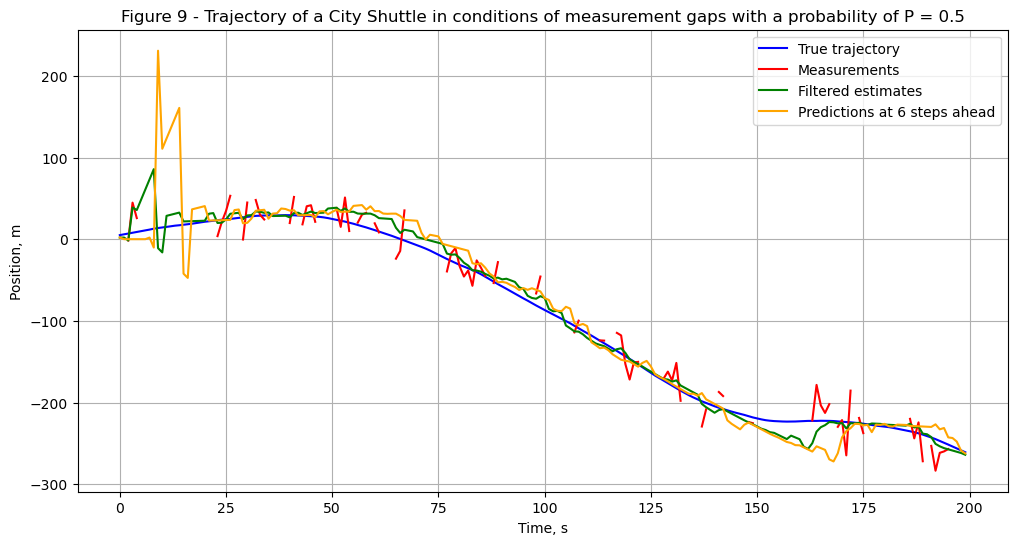

In [94]:
#Plots of true coordinates, measurements, filtered estimates and predictions at 6 steps ahead
plt.figure(figsize=(12, 6))
plt.plot(x_real, color="blue",  label='True trajectory')
plt.plot(z, color='red', label='Measurements')
plt.plot(X[:,0,0], color='green',  label='Filtered estimates')
plt.plot(X_tuned[:,0,0], color='orange',  label='Predictions at 6 steps ahead')
plt.title('Figure 9 - Trajectory of a City Shuttle in conditions of measurement gaps with a probability of P = 0.5')
plt.xlabel('Time, s')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

In [95]:
#calculate error for filtration, prediction and prediction of 6-step ahead
M=500
error_filt=np.zeros((M,steps))
error_pred=np.zeros((M,steps))
error_tuned=np.zeros((M,steps))
fin_err_filt=np.zeros(steps)
fin_err_pred=np.zeros(steps)
fin_err_tuned=np.zeros(steps)
for o in range(M):
    #generating_trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z = np.zeros(steps)
    p = 0.5
    for i in range(0,steps):
        xi =  np.random.random()
        if xi > p:
            z[i] = x_real[i] + np.random.normal(0, 20)
        else:
            z[i] = np.nan
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matri
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    X_pred = np.zeros((len(x_real), 2, 1))
    X_tuned = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0]])
    X_pred[0]=np.matrix([[2],[0]])
    X_tuned[0:m]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[100, 0], [0, 100]])
    P_viz=np.zeros((steps, 2, 2))
    P_viz[0]=np.matrix([[100, 0], [0, 100]])
    P_tuned=np.zeros((steps, 2, 2))
    P_tuned[0:m]=np.matrix([[100, 0], [0, 100]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        X_pred[i] = fi@X[i-1]
        if i>1:
            error_pred[o,i]=(x_real[i]-X_pred[i,0,0])**2
        P[i]=(fi@P[i-1]@fi.T)+Q
        P_viz[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        if not np.isnan(z[i]):
            X[i]=X[i]+K[i]*(z[i]-h@X[i])
            P[i]=(np.identity(2)-K[i]@h)@P[i]
        if i < steps-m+1:
            X_tuned[i+m-1]=(fi**6)@X[i]
            P_tuned[i+m-1] = calc_err_finder(P[i], fi, Q)
        if i > 1:
            error_filt[o, i] = (x_real[i]-X[i,0,0])**2
            error_tuned[o, i] = (x_real[i]-X_tuned[i,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_err_filt[i]=fin_err_filt[i]+((1/(M-1))*error_filt[j,i])
        fin_err_pred[i]=fin_err_pred[i]+((1/(M-1))*error_pred[j,i])
        fin_err_tuned[i]=fin_err_tuned[i]+((1/(M-1))*error_tuned[j,i])
    fin_err_filt[i] = sqrt(fin_err_filt[i])
    fin_err_pred[i] = sqrt(fin_err_pred[i])
    fin_err_tuned[i] = sqrt(fin_err_tuned[i])

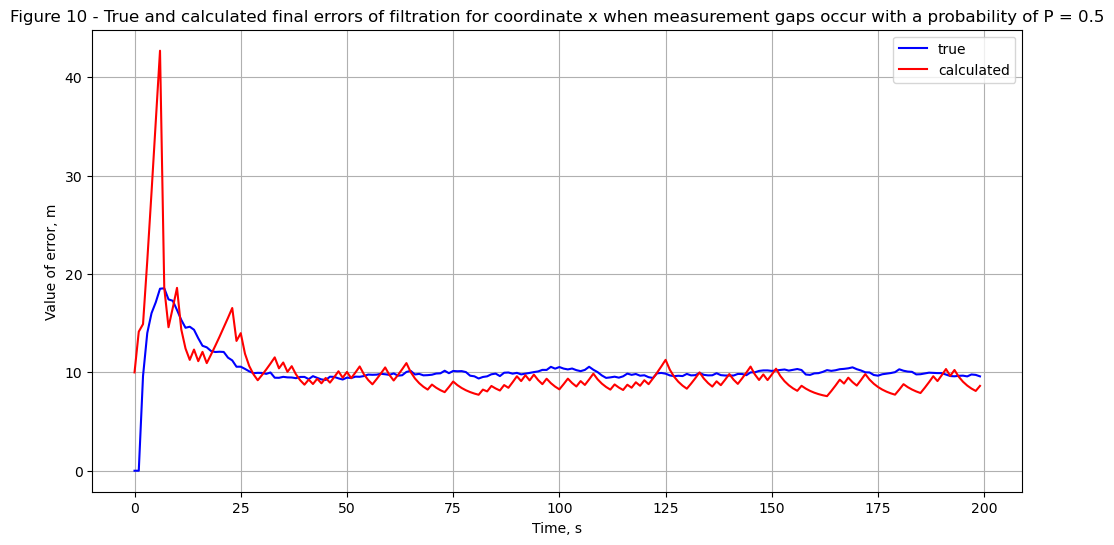

In [96]:
#Plot of the final error of filtration
plt.figure(figsize=(12, 6))
plt.plot(fin_err_filt, color="blue", label='true')
plt.plot(np.sqrt(P[:, 0, 0]), color="red", label='calculated')
plt.title('Figure 10 - True and calculated final errors of filtration for coordinate x when measurement gaps occur with a probability of P = 0.5')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.grid()
plt.legend()
plt.show()

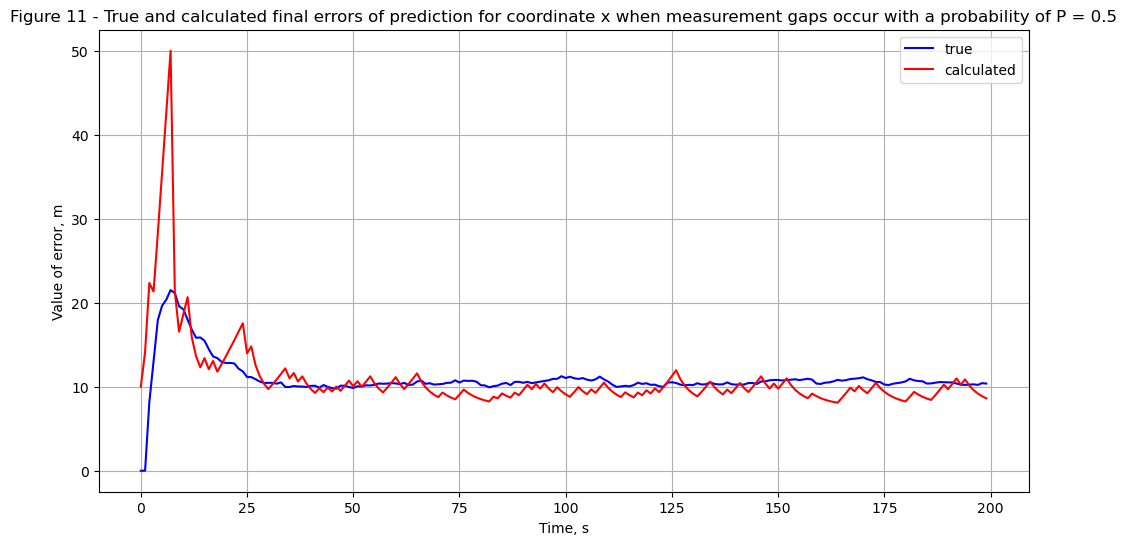

In [97]:
#Plot of the final error of prediction
plt.figure(figsize=(12, 6))
plt.plot(fin_err_pred, color="blue", label='true')
plt.plot(np.sqrt(P_viz[:, 0, 0]), color="red", label='calculated')
plt.title('Figure 11 - True and calculated final errors of prediction for coordinate x when measurement gaps occur with a probability of P = 0.5')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.grid()
plt.legend()
plt.show()

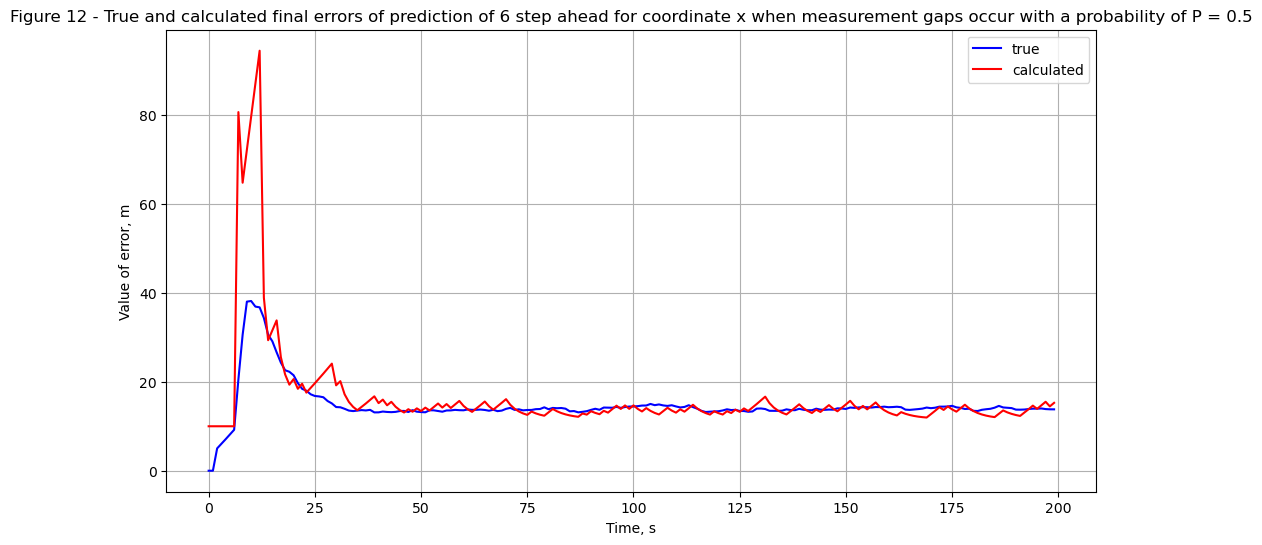

In [98]:
#Plot of the final error of prediction of 6-step ahead
plt.figure(figsize=(12, 6))
plt.plot(fin_err_tuned, color="blue", label='true')
plt.plot(np.sqrt(P_tuned[:, 0, 0]), color="red", label='calculated')
plt.title('Figure 12 - True and calculated final errors of prediction of 6 step ahead for coordinate x when measurement gaps occur with a probability of P = 0.5')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.grid()
plt.legend()
plt.show()

Let's check with a measurement gaps probability $P = 0.7$.

In [99]:
#generating_measurements
z = np.zeros(steps)
p = 0.7
for i in range(0,steps):
    xi =  np.random.random()
    if xi > p:
        z[i] = x_real[i] + np.random.normal(0, 20)
    else:
        z[i] = np.nan

In [100]:
#transition matrix
fi=np.matrix([[1,t],[0,1]])
#input matrix
g=np.matrix([[(t**2)/2],[t]])
#observation matrix
h=np.matrix([1,0])
#state vector
X = np.zeros((len(x_real), 2, 1))
X_tuned = np.zeros((len(x_real), 2, 1))
for i in range(len(x_real)):
    X[i] = np.array([[x_real[i]], [v_real[i]]])

In [101]:
#Initial filtered estimate
X[0]=np.matrix([[2],[0]])
X_tuned[0]=np.matrix([[2],[0]])
#Filtration error covariance matrix
P=np.zeros((steps, 2, 2))
P[0]=np.matrix([[10000, 0], [0, 10000]])
#Covariance matrix
Q=(g@g.T)*(0.2**2)
R = np.array(20**2)
K = np.zeros((steps, 2, 1))
m = 7
for i in range(1,len(x_real)):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)/E
    if not np.isnan(z[i]):
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
    if i < steps-m+1:
        X_tuned[i+m-1]=(fi**6)@X[i]

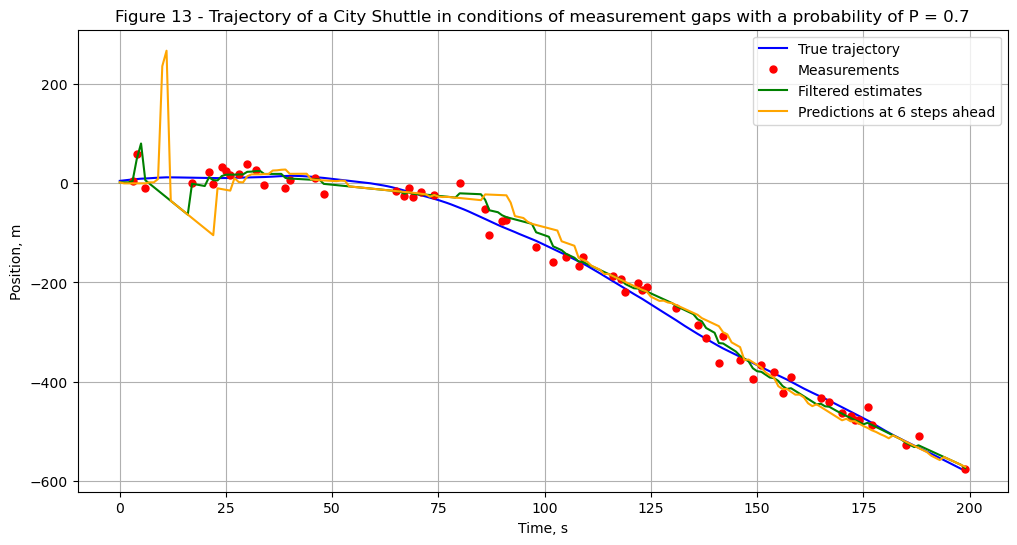

In [102]:
#Plots of true coordinates, measurements, filtered estimates and predictions at 6 steps ahead
plt.figure(figsize=(12, 6))
plt.plot(x_real, color="blue",  label='True trajectory')
plt.plot(z, 'ro',markersize=5, label='Measurements')
plt.plot(X[:,0,0], color='green',  label='Filtered estimates')
plt.plot(X_tuned[:,0,0], color='orange',  label='Predictions at 6 steps ahead')
plt.title('Figure 13 - Trajectory of a City Shuttle in conditions of measurement gaps with a probability of P = 0.7')
plt.xlabel('Time, s')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

In [103]:
#calculate error for filtration, prediction and prediction of 6-step ahead
M=500
error_filt=np.zeros((M,steps))
error_pred=np.zeros((M,steps))
error_tuned=np.zeros((M,steps))
fin_err_filt=np.zeros(steps)
fin_err_pred=np.zeros(steps)
fin_err_tuned=np.zeros(steps)
for o in range(M):
    #generating_trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z = np.zeros(steps)
    p = 0.7
    for i in range(0,steps):
        xi =  np.random.random()
        if xi > p:
            z[i] = x_real[i] + np.random.normal(0, 20)
        else:
            z[i] = np.nan
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matri
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    X_pred = np.zeros((len(x_real), 2, 1))
    X_tuned = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0]])
    X_pred[0]=np.matrix([[2],[0]])
    X_tuned[0:m]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[100, 0], [0, 100]])
    P_viz=np.zeros((steps, 2, 2))
    P_viz[0]=np.matrix([[100, 0], [0, 100]])
    P_tuned=np.zeros((steps, 2, 2))
    P_tuned[0:m]=np.matrix([[100, 0], [0, 100]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        X_pred[i] = fi@X[i-1]
        if i>1:
            error_pred[o,i]=(x_real[i]-X_pred[i,0,0])**2
        P[i]=(fi@P[i-1]@fi.T)+Q
        P_viz[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        if not np.isnan(z[i]):
            X[i]=X[i]+K[i]*(z[i]-h@X[i])
            P[i]=(np.identity(2)-K[i]@h)@P[i]
        if i < steps-m+1:
            X_tuned[i+m-1]=(fi**6)@X[i]
            P_tuned[i+m-1] = calc_err_finder(P[i], fi, Q)
        if i > 1:
            error_filt[o, i] = (x_real[i]-X[i,0,0])**2
            error_tuned[o, i] = (x_real[i]-X_tuned[i,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_err_filt[i]=fin_err_filt[i]+((1/(M-1))*error_filt[j,i])
        fin_err_pred[i]=fin_err_pred[i]+((1/(M-1))*error_pred[j,i])
        fin_err_tuned[i]=fin_err_tuned[i]+((1/(M-1))*error_tuned[j,i])
    fin_err_filt[i] = sqrt(fin_err_filt[i])
    fin_err_pred[i] = sqrt(fin_err_pred[i])
    fin_err_tuned[i] = sqrt(fin_err_tuned[i])

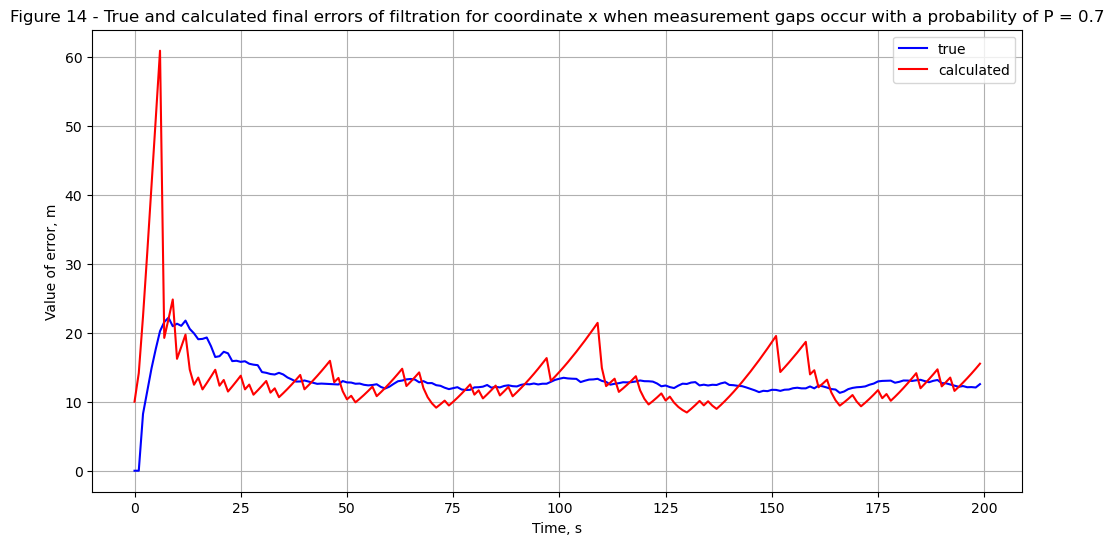

In [104]:
#Plot of the final error of filtration
plt.figure(figsize=(12, 6))
plt.plot(fin_err_filt, color="blue", label='true')
plt.plot(np.sqrt(P[:, 0, 0]), color="red", label='calculated')
plt.title('Figure 14 - True and calculated final errors of filtration for coordinate x when measurement gaps occur with a probability of P = 0.7')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.grid()
plt.legend()
plt.show()

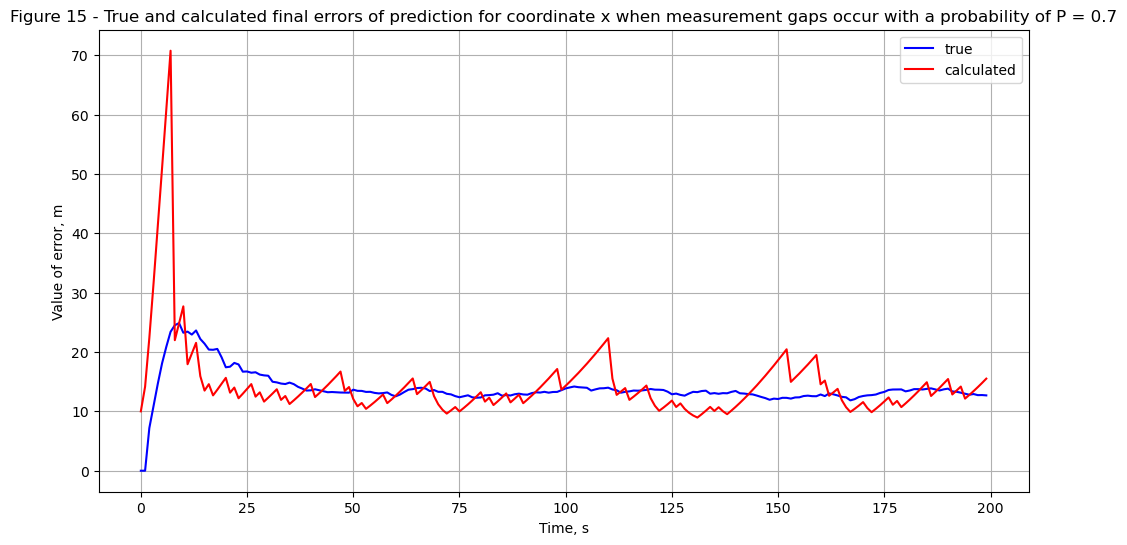

In [105]:
#Plot of the final error of prediction
plt.figure(figsize=(12, 6))
plt.plot(fin_err_pred, color="blue", label='true')
plt.plot(np.sqrt(P_viz[:, 0, 0]), color="red", label='calculated')
plt.title('Figure 15 - True and calculated final errors of prediction for coordinate x when measurement gaps occur with a probability of P = 0.7')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.grid()
plt.legend()
plt.show()

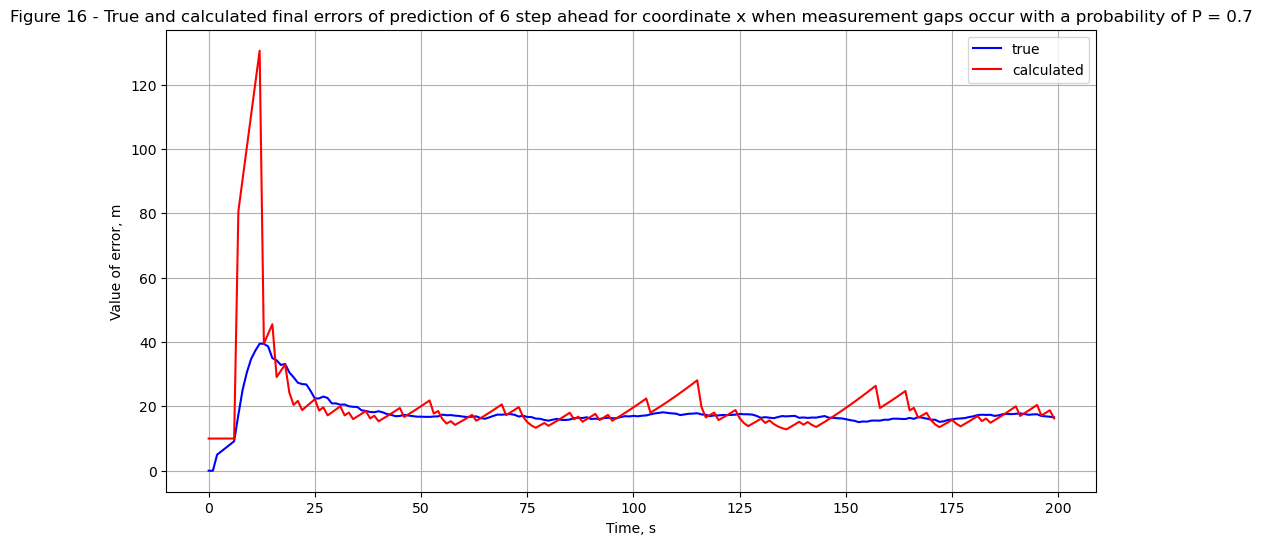

In [106]:
#Plot of the final error of prediction of 6-step ahead
plt.figure(figsize=(12, 6))
plt.plot(fin_err_tuned, color="blue", label='true')
plt.plot(np.sqrt(P_tuned[:, 0, 0]), color="red", label='calculated')
plt.title('Figure 16 - True and calculated final errors of prediction of 6 step ahead for coordinate x when measurement gaps occur with a probability of P = 0.7')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.grid()
plt.legend()
plt.show()

As we can see, as the probability of missing measurements increases, the error increases, so we can conclude that the more gaps there are, the worse the Kalman filter works. We also observe an increase in the amplitude of fluctuations in the calculated error, which are caused by skipping the filtering stage in the Kalman filter at a time when measurements are unavailable. When predicting 6 steps ahead, we see the biggest error compared to the rest of the cases. 

**Conclusion:**

Thus, we discovered that even if measurements are missed due to technical problems with the measuring devices, we can still obtain data using the prediction stage of the Kalman filter. However, the higher the frequency of missed measurements, the error increases, thereby reducing the performance of the Kalman filter. Thus, we saw that even when losing a large number of measurements, the Kalman filter is able to work stably, while reducing, rather than accumulating, the covariance error.

**Learning log:**

What We learned:

We have explored how to struggle with missing measurements in the Kalman filter and have discovered the importance of the correction stage in the Kalman filter, as measurements help reduce the error in the Kalman filter.

We also found that the more measurement gaps, the lower the filtering accuracy. We also realized where the fluctuations in the calculated error come from.

What difficulties We faced:

We had difficulty understanding the mathematical dependencies and implementing of finding the calculated prediction error 6 steps ahead.

It was also difficult to visually evaluate the effectiveness of the filter using plots of true coordinates, measurements, filtered estimates and predictions at 6 steps ahead, when measurements were lost with some probability.